In [20]:
import tensorflow as tf
print(tf.__version__) #checking tensorflow version
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus)) # check if the GPU is available

if gpus:
    print("GPU Details:", gpus)
else:
    print("No GPU detected. TensorFlow is running on CPU.")

2.20.0
Num GPUs Available:  1
GPU Details: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
""""external libaries import configuration"""
import tensorflow as tf
from tensorflow import keras # type: ignore
from tensorflow.keras import layers  # type: ignore

import numpy as np
import matplotlib.pyplot as plt

import os
import pathlib

In [22]:
BASE_DIR = "/mnt/d/US_Banknote_Classification/US_BANK_NOTE_CLASSIFICATION/Data"
DATA_DIR = f"{BASE_DIR}/USA currency"
TEST_DIR = f"{BASE_DIR}/Test_Set"

img_size = (160, 160)
batch_size = 32
SEED = 123
VAL_SPLIT = 0.1

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int'
)

class_names = train_ds.class_names

# Test_Set mirrors the training class folders, so the same class_names are passed
# explicitly to keep the integer labels aligned across all three datasets.
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int',
    class_names=class_names,
    shuffle=False
)

IMAGE_EXTS = ('.bmp', '.gif', '.jpeg', '.jpg', '.png')

def count_images(directory):
    """Count the image files a loader would pick up under a directory."""
    return sum(1 for p in pathlib.Path(directory).rglob('*')
               if p.suffix.lower() in IMAGE_EXTS)

# Counts come from the directories rather than from the dataset objects: Keras
# attaches .file_paths to whatever it returns, and any later .map/.cache/.prefetch
# hands back a new object without it.
n_total = count_images(DATA_DIR)
n_val = int(VAL_SPLIT * n_total)
n_train = n_total - n_val
n_test = count_images(TEST_DIR)

# The split is a prefix/suffix slice of one shuffled list, so train and val are
# disjoint by construction as long as the two parts still account for every file.
assert n_train + n_val == n_total, f"split does not cover the data: {n_train} + {n_val} != {n_total}"
print(f"train: {n_train}  val: {n_val}  test: {n_test}")

print("class_names:", class_names)


Found 3906 files belonging to 6 classes.
Using 3516 files for training.
Found 3906 files belonging to 6 classes.
Using 390 files for validation.
Found 6 files belonging to 6 classes.
train: 3516  val: 390  test: 6
class_names: ['1 Dollar', '10 Dollar', '100 Dollar', '2 Doolar', '5 Dollar', '50 Dollar']


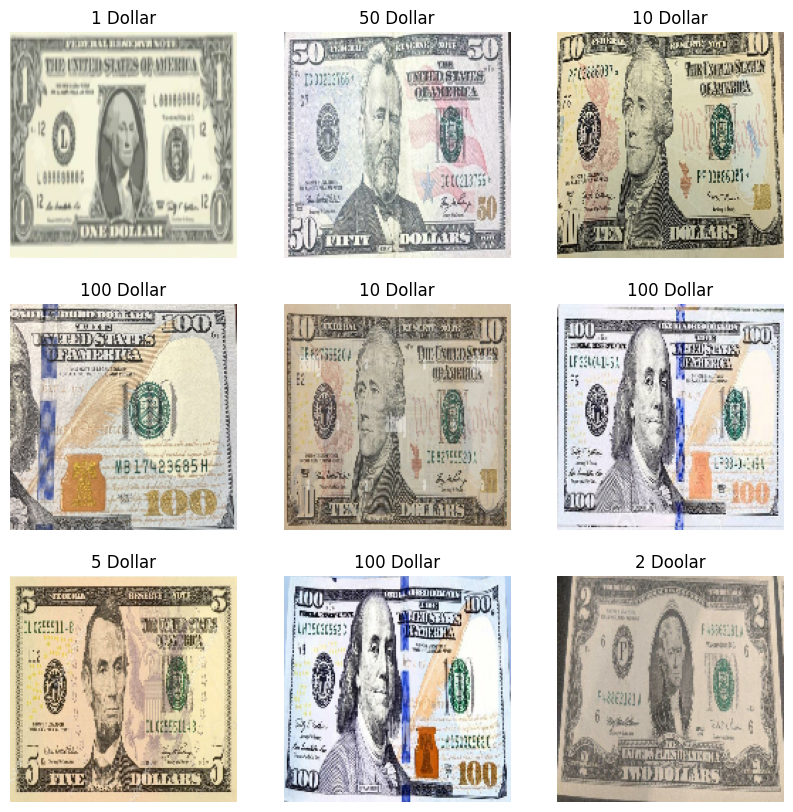

In [23]:

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): #Grabs only the first batch 
                                       # from the dataset. If your batch size is 32, this single step pulls 32 images and 32 labels.
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

In [24]:
#Apply Vgg16 preprocessing
# NOTE: this rebinds the dataset names in place, so cell 2 must be re-run
# before re-running this cell (otherwise preprocessing gets applied twice).
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y))   # was assigned to `validation_ds`, which nothing used
test_ds  = test_ds.map(lambda x, y: (preprocess_input(x), y))

In [25]:
Autotune = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=Autotune)
test_ds = test_ds.cache().prefetch(buffer_size=Autotune)
val_ds = val_ds.cache().prefetch(buffer_size=Autotune)

In [26]:

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [27]:
from tensorflow.keras.applications import VGG16
base_model = VGG16(
    input_shape=img_size + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

In [28]:
input = tf.keras.Input(shape=img_size + (3,))
x = data_augmentation(input)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)  # Regularize with dropout
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(len(class_names), activation='softmax')(x)  # Assuming multi-class classification
model = tf.keras.Model(input, output)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,126 (56.39 MB)

 Trainable params: 66,438 (259.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:

EPOCHS = 50


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    
)

Epoch 1/50


110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - accuracy: 0.5611 - loss: 2.1143 - val_accuracy: 0.8308 - val_loss: 0.6177
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - accuracy: 0.7668 - loss: 0.7677 - val_accuracy: 0.8667 - val_loss: 0.4352
Epoch 3/50
 76/110 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.8139 - loss: 0.5997

In [ ]:
import pathlib
import numpy as np

data_dir = pathlib.Path("/mnt/d/US_Banknote_Classification/US_BANK_NOTE_CLASSIFICATION/Data/USA currency")
class_names = sorted([item.name for item in data_dir.glob("*") if item.is_dir()])
print(class_names)

all_paths = []
all_labels = []

for label_idx, class_name in enumerate(class_names):
    class_files = list((data_dir / class_name).glob("*"))
    all_paths.extend([str(f) for f in class_files])
    all_labels.extend([label_idx] * len(class_files))

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)
print(f"Total images: {len(all_paths)}")


['1 Dollar', '10 Dollar', '100 Dollar', '2 Doolar', '5 Dollar', '50 Dollar']
Total images: 3906


## Evaluation


Accuracy:  0.9744
Precision: 0.9752
Recall:    0.9744
F1 Score:  0.9745


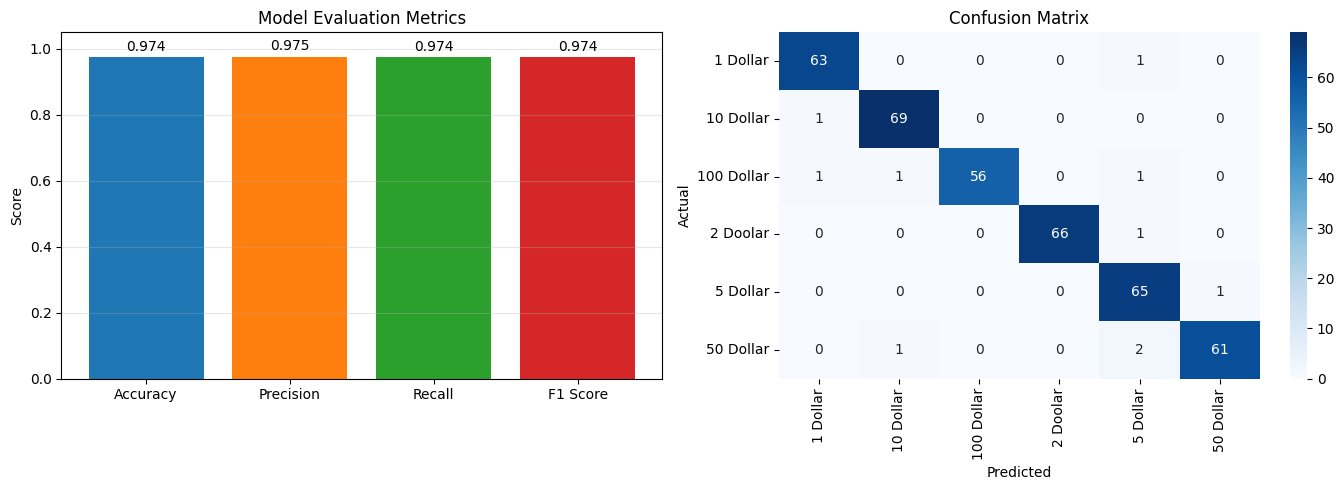

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Extract labels and predictions in a single pass to ensure matching lengths
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.append(labels.numpy())
    y_pred_probs.append(preds)

y_true = np.concatenate(y_true, axis=0).flatten()
y_pred_probs = np.concatenate(y_pred_probs, axis=0)

# Determine predictions based on shape (Binary vs Multi-class)
if y_pred_probs.ndim > 1 and y_pred_probs.shape[1] > 1:
    y_pred = np.argmax(y_pred_probs, axis=1)
    average_mode = "weighted"  # Required for multi-class metrics
else:
    y_pred = (y_pred_probs.flatten() >= 0.5).astype(int)
    average_mode = "binary"

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average=average_mode)
rec = recall_score(y_true, y_pred, average=average_mode)
f1 = f1_score(y_true, y_pred, average=average_mode)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# --- Plot 1: Metrics bar chart ---
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [acc, prec, rec, f1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(metrics, values, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Model Evaluation Metrics")
axes[0].set_ylabel("Score")
axes[0].grid(axis="y", alpha=0.3)

for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
                 ha="center", fontsize=10)

# --- Plot 2: Confusion matrix heatmap ---
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()